In [ ]:
import os
import sys
print(os.getcwd())

patient_pipeline_path = "c:/Users/Soz/OneDrive - Radboud Universiteit/Bureaublad/BSc_Thesis/Code/BSc_Thesis_Project/ERP_analysis_code"

sys.path.append(os.path.abspath(patient_pipeline_path))  

from patient_pipeline.results.results_functions import extract_ews_v3, extract_tws_v3
from patient_pipeline.results.db import patients_db

import pickle
import numpy as np
import matplotlib.pyplot as plt
# from patient_pipeline.results.results_functions import extract_ews_v3, extract_tws_v3
# from patient_pipeline.results.db import patients_db



c:\Users\Soz\OneDrive - Radboud Universiteit\Bureaublad\BSc_Thesis\Code\BSc_Thesis_Project\ERP_analysis_code\patient_pipeline\results_UC_pilot


dict_keys(['p9_cc_s3', 'p9_cc_s4', 'p9_cc_s5', 'p9_cc_s6', 'p9_cc_s7', 'p9_cc_s8', 'p9_cc_s9', 'p9_cc_s10', 'p9_cc_s11', 'p9_cc_s12', 'p9_cc_s13', 'p9_cc_s14', 'p9_cc_s15', 'p9_cc_s16', 'p9_cc_s17'])
dict_keys(['p9_cc_s3', 'p9_cc_s4', 'p9_cc_s5', 'p9_cc_s6', 'p9_cc_s7', 'p9_cc_s8', 'p9_cc_s9', 'p9_cc_s10', 'p9_cc_s11', 'p9_cc_s12', 'p9_cc_s13', 'p9_cc_s14', 'p9_cc_s15', 'p9_cc_s16', 'p9_cc_s17'])
dict_keys(['p9_cc_s3', 'p9_cc_s4', 'p9_cc_s5', 'p9_cc_s6', 'p9_cc_s7', 'p9_cc_s8', 'p9_cc_s9', 'p9_cc_s10', 'p9_cc_s11', 'p9_cc_s12', 'p9_cc_s13', 'p9_cc_s14', 'p9_cc_s15', 'p9_cc_s16', 'p9_cc_s17'])
dict_keys(['p9_cc_s3', 'p9_cc_s4', 'p9_cc_s5', 'p9_cc_s6', 'p9_cc_s7', 'p9_cc_s8', 'p9_cc_s9', 'p9_cc_s10', 'p9_cc_s11', 'p9_cc_s12', 'p9_cc_s13', 'p9_cc_s14', 'p9_cc_s15', 'p9_cc_s16', 'p9_cc_s17'])


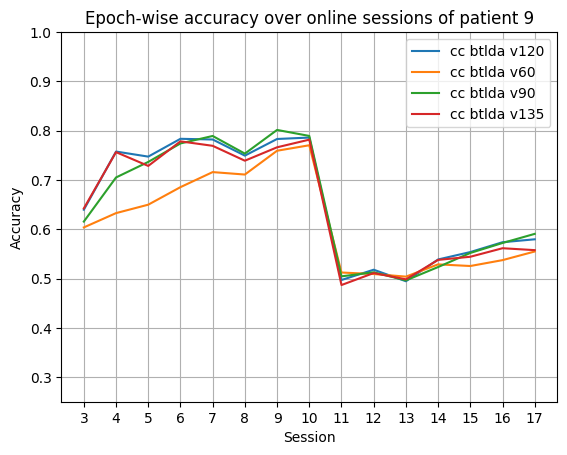

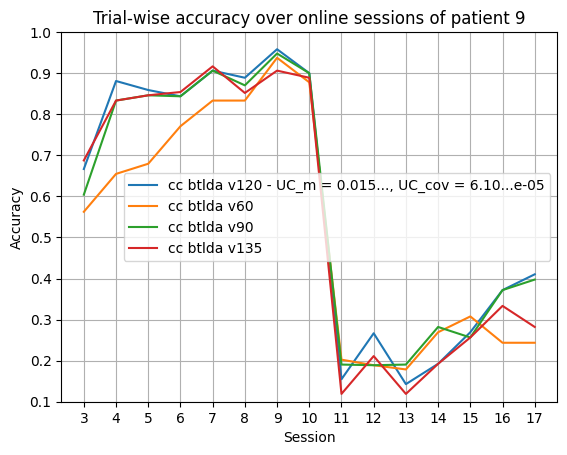

In [5]:
p =9
for id in patients_db:
    if id==p:
        lon = patients_db.get(id).get('last_session')-1

# tr long ival range
v0 = 120
with open(f'v{v0}/pickles/p{p}_cc_v{v0}.pkl', 'rb') as f:
    p_cc_v0 = pickle.load(f) 

print(p_cc_v0.keys())

v1 = 60
with open(f'v{v1}/pickles/p{p}_cc_v{v1}.pkl', 'rb') as f:
    p_cc_v1 = pickle.load(f) 

print(p_cc_v1.keys())

v2 = 90
with open(f'v{v2}/pickles/p{p}_cc_v{v2}.pkl', 'rb') as f:
    p_cc_v2 = pickle.load(f) 

print(p_cc_v2.keys())

v3 = 135
with open(f'v{v3}/pickles/p{p}_cc_v{v3}.pkl', 'rb') as f:
    p_cc_v3 = pickle.load(f) 

print(p_cc_v3.keys())


ews_cc_v0= extract_ews_v3(performances= p_cc_v0, patient_nr=p, last_online_session=lon, strategy="cc")
tws_cc_v0 = extract_tws_v3(performances= p_cc_v0, patient_nr=p, last_online_session=lon, strategy="cc")

ews_cc_v1= extract_ews_v3(performances= p_cc_v1, patient_nr=p, last_online_session=lon, strategy="cc")
tws_cc_v1 = extract_tws_v3(performances= p_cc_v1, patient_nr=p, last_online_session=lon, strategy="cc")


ews_cc_v2= extract_ews_v3(performances= p_cc_v2, patient_nr=p, last_online_session=lon, strategy="cc")
tws_cc_v2 = extract_tws_v3(performances= p_cc_v2, patient_nr=p, last_online_session=lon, strategy="cc")
ews_cc_v3= extract_ews_v3(performances= p_cc_v3, patient_nr=p, last_online_session=lon, strategy="cc")
tws_cc_v3 = extract_tws_v3(performances= p_cc_v3, patient_nr=p, last_online_session=lon, strategy="cc")

# Plot 1: epoch-wise
plt.figure()
plt.plot(ews_cc_v0, label=f"cc btlda v{v0}")
plt.plot(ews_cc_v1, label=f"cc btlda v{v1}")
plt.plot(ews_cc_v2, label=f"cc btlda v{v2}")
plt.plot(ews_cc_v3, label=f"cc btlda v{v3}")
plt.title(f"Epoch-wise accuracy over online sessions of patient {p}")
plt.legend()
plt.xlabel("Session")
plt.ylabel("Accuracy")
plt.xticks(np.arange(0,lon-2),np.arange(3,lon+1))
plt.ylim((0.25,1))
plt.grid()


# Plot 2: Trial-wise acc 

plt.figure()

plt.plot(tws_cc_v0, label=f"cc btlda v{v0} - UC_m = 0.015..., UC_cov = 6.10...e-05")
plt.plot(tws_cc_v1, label=f"cc btlda v{v1}")
plt.plot(tws_cc_v2, label=f"cc btlda v{v2}")
plt.plot(tws_cc_v3, label=f"cc btlda v{v3}")

plt.title(f"Trial-wise accuracy over online sessions of patient {p}")
plt.xlabel("Session")
plt.ylabel("Accuracy")
plt.ylim((0.1,1))
plt.grid()
plt.xticks(np.arange(0,lon-2),np.arange(3,lon+1))
#plt.yticks(np.arange(0,1.1,0.1))
#plt.xticks([0,1,2,3,4,5,6,7,8,9,10],[3,4,5,6,7,8,9,10,11,12,13])
#plt.xticks(np.arange(0,last_on_session-2),np.arange(3,last_on_session+1))
plt.legend(bbox_to_anchor=(1, 1.05))
plt.legend()
plt.show()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219,

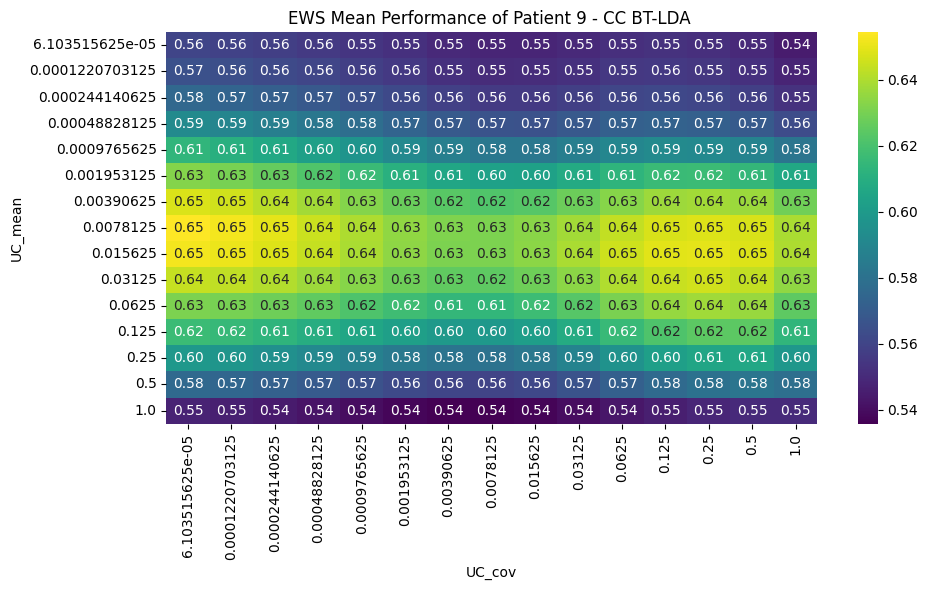

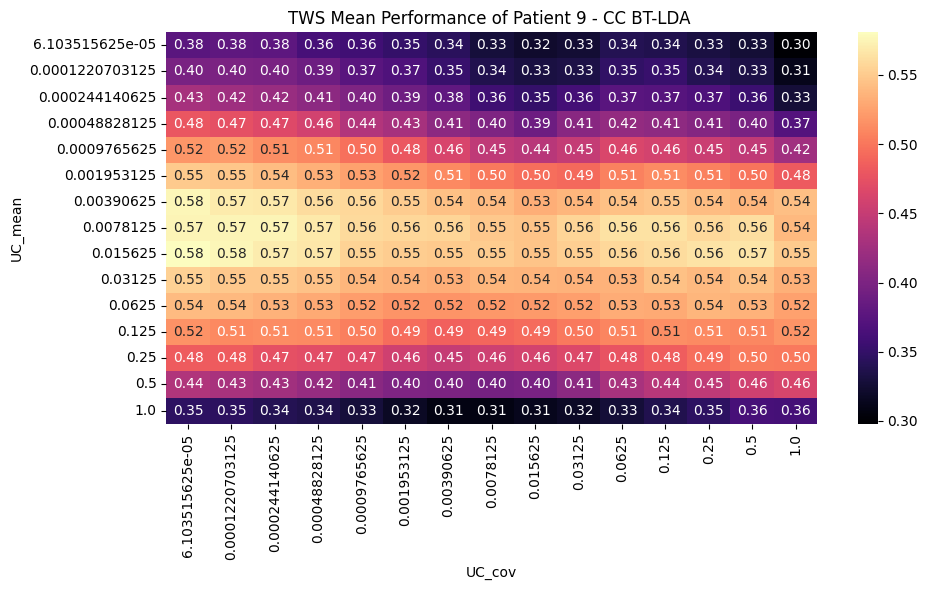

In [52]:
import pandas as pd
import seaborn as sns


def create_dict_results_UC_pairs(p, lon):
    with open(f'versions.pkl', 'rb') as f:
        versions_dict = pickle.load(f) 

    print(versions_dict.keys())
    #UC_means = []
    #UC_covs = []
    UC_pairs = []
    data = []

    for v,version in enumerate(versions_dict.keys()):
        UC_m = versions_dict.get(version).get("UC_mean")
        UC_c = versions_dict.get(version).get("UC_cov")

        with open(f'v{v}/pickles/p{p}_cc_v{v}.pkl', 'rb') as f:
            p_version_scores = pickle.load(f) 

        ews_cc= extract_ews_v3(performances= p_version_scores, patient_nr=p, last_online_session=lon, strategy="cc")
        tws_cc = extract_tws_v3(performances= p_version_scores, patient_nr=p, last_online_session=lon, strategy="cc")

        data.append({
            "v": v,
            "UC_mean": UC_m,
            "UC_cov": UC_c,
            "EWS_mean": ews_cc[:].mean(),
            "TWS_mean": tws_cc[:].mean()
        })

        print(f"UC_mean: {UC_m} - UC_cov: {UC_c}")
        #UC_means.append(UC_m)
        #UC_covs.append(UC_c)
        UC_pairs.append(np.array([UC_m, UC_c]))

    return data

def create_dataframe(dict):
    df_long = pd.DataFrame(dict)
    return df_long

# Use
p = 9
for id in patients_db:
    if id==p:
        lon = patients_db.get(id).get('last_session')-1

data_dict = create_dict_results_UC_pairs(p=p, lon=lon)
df = create_dataframe(data_dict)
df.to_csv("cc_pilot_results.csv")

pivot_ews = df.pivot(index="UC_mean", columns="UC_cov", values="EWS_mean")

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_ews, annot=True, fmt=".2f", cmap="viridis")
plt.title("EWS Mean Performance of Patient 9 - CC BT-LDA ")
plt.ylabel("UC_mean")
plt.xlabel("UC_cov")
plt.tight_layout()
plt.show()

pivot_tws = df.pivot(index="UC_mean", columns="UC_cov", values="TWS_mean")

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_tws, annot=True, fmt=".2f", cmap="magma")
# HP (sessions 11-17)
# 6D (sessions 3-10)
plt.title("TWS Mean Performance of Patient 9 - CC BT-LDA ")
plt.ylabel("UC_mean")
plt.xlabel("UC_cov")
plt.tight_layout()
plt.show()

[6.10351562e-05 1.22070312e-04 2.44140625e-04 4.88281250e-04
 9.76562500e-04 1.95312500e-03 3.90625000e-03 7.81250000e-03
 1.56250000e-02 3.12500000e-02 6.25000000e-02 1.25000000e-01
 2.50000000e-01 5.00000000e-01 1.00000000e+00]
[6.10351562e-05 1.22070312e-04 2.44140625e-04 4.88281250e-04
 9.76562500e-04 1.95312500e-03 3.90625000e-03 7.81250000e-03
 1.56250000e-02 3.12500000e-02 6.25000000e-02 1.25000000e-01
 2.50000000e-01 5.00000000e-01 1.00000000e+00]


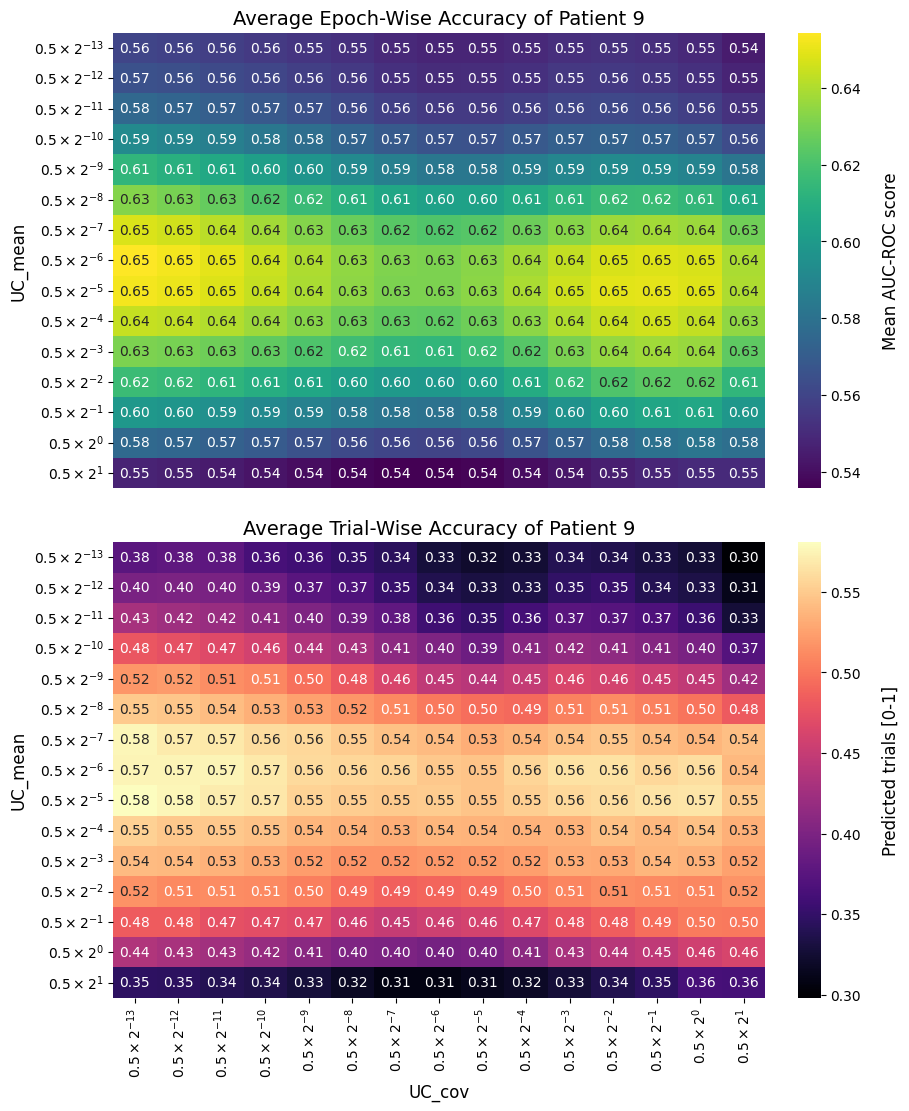

In [56]:
# Plot heatmap
from uc_visualization import plot_reduced_heatmaps
pivot_ews = df.pivot(index="UC_mean", columns="UC_cov", values="EWS_mean")

UC_mean_exponents = np.arange(-13, 2)  
UC_mean_range = 0.5 * (2.0 ** UC_mean_exponents)
UC_cov_exponents = np.arange(-13,2)  
UC_cov_range = 0.5 * (2.0 ** UC_cov_exponents)
print(UC_mean_range)
print(UC_cov_range)

patient_title = "Patient 9"


# Create subplots with shared x-axis
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(9, 11), sharex=True, constrained_layout=True)

# Plot first heatmap (Epoch-Wise Score)
sns.heatmap(pivot_ews, annot=True, fmt=".2f", cmap="viridis", ax=ax1, cbar_kws={"label": "Mean AUC-ROC score"})
ax1.set_yticks(np.arange(len(UC_mean_range)) + 0.5)
ax1.set_yticklabels([fr"$0.5 \times 2^{{{y}}}$" for y in UC_mean_exponents], rotation=0, fontsize=10)
cbar = ax1.collections[0].colorbar
cbar.set_label("Mean AUC-ROC score", fontsize=12, rotation=90, labelpad=15)
ax1.set_xlabel(" ")
ax1.set_xticklabels([])
ax1.tick_params(axis='x', bottom=False, top=False)
ax1.set_ylabel("UC_mean", fontsize=12)
ax1.set_title(f"Average Epoch-Wise Accuracy of {patient_title}", fontsize=14)

# Plot second heatmap (Trial-Wise Score)
sns.heatmap(pivot_tws, annot=True, fmt=".2f", cmap="magma", ax=ax2, cbar_kws={"label": "Predicted trials [0-1]"})
ax2.set_yticks(np.arange(len(UC_mean_range)) + 0.5)
ax2.set_yticklabels([fr"$0.5 \times 2^{{{y}}}$" for y in UC_mean_exponents], rotation=0, fontsize=10)
ax2.set_xticks(np.arange(len(UC_cov_range)) + 0.5)
ax2.set_xticklabels([fr"$0.5 \times 2^{{{x}}}$" for x in UC_cov_exponents], rotation=90, fontsize=10)
cbar = ax2.collections[0].colorbar
cbar.set_label("Predicted trials [0-1]", fontsize=12, rotation=90, labelpad=15)
ax2.set_xlabel("UC_cov", fontsize=12)
ax2.set_ylabel("UC_mean", fontsize=12)
ax2.set_title(f"Average Trial-Wise Accuracy of {patient_title}", fontsize=14)

plt.savefig(f"heatmap_pilot_p9.svg", bbox_inches='tight')
plt.savefig(f"heatmap_pilot_p9.pdf", bbox_inches='tight')
plt.savefig(f"heatmap_pilot_p9.png", dpi=600, bbox_inches='tight')


# # Plot heatmap
# plt.figure(figsize=(10, 6))
# sns.heatmap(pivot_ews, annot=True, fmt=".2f", cmap="viridis")
# plt.title("EWS Mean Performance of Patient 9 - CC BT-LDA ")
# plt.ylabel("UC_mean")
# plt.xlabel("UC_cov")
# plt.tight_layout()
# plt.show()

# plt.savefig(f"heatmap_pilot_p9_ews.svg", bbox_inches='tight')
# plt.savefig(f"heatmap_pilot_p9_ews.svg", dpi=600, bbox_inches='tight')

# pivot_tws = df.pivot(index="UC_mean", columns="UC_cov", values="TWS_mean")

# # Plot heatmap
# plt.figure(figsize=(10, 6))
# sns.heatmap(pivot_tws, annot=True, fmt=".2f", cmap="magma")
# # HP (sessions 11-17)
# # 6D (sessions 3-10)
# plt.title("TWS Mean Performance of Patient 9 - CC BT-LDA ")
# plt.ylabel("UC_mean")
# plt.xlabel("UC_cov")
# plt.tight_layout()
# plt.show()


# plt.savefig(f"heatmap_pilot_p9_tws.svg", bbox_inches='tight')
# plt.savefig(f"heatmap_pilot_p9_tws.svg", dpi=600, bbox_inches='tight')


## Separating the dataset at session 11 (separate 6D - HP)

In [21]:
def create_dict_results_UC_pairs(p, lon):
    with open(f'versions.pkl', 'rb') as f:
        versions_dict = pickle.load(f) 

    print(versions_dict.keys())
    #UC_means = []
    #UC_covs = []
    UC_pairs = []
    data = []

    for v,version in enumerate(versions_dict.keys()):
        UC_m = versions_dict.get(version).get("UC_mean")
        UC_c = versions_dict.get(version).get("UC_cov")

        with open(f'v{v}/pickles/p{p}_cc_v{v}.pkl', 'rb') as f:
            p_version_scores = pickle.load(f) 

        ews_cc= extract_ews_v3(performances= p_version_scores, patient_nr=p, last_online_session=lon, strategy="cc")
        tws_cc = extract_tws_v3(performances= p_version_scores, patient_nr=p, last_online_session=lon, strategy="cc")

        data.append({
            "v": v,
            "UC_mean": UC_m,
            "UC_cov": UC_c,
            "EWS_mean": ews_cc[8:].mean(),
            "TWS_mean": tws_cc[8:].mean()
        })

        print(f"UC_mean: {UC_m} - UC_cov: {UC_c}")
        #UC_means.append(UC_m)
        #UC_covs.append(UC_c)
        UC_pairs.append(np.array([UC_m, UC_c]))

    return data

def create_dataframe(dict):
    df_long = pd.DataFrame(dict)
    return df_long

# Use
p = 9
for id in patients_db:
    if id==p:
        lon = patients_db.get(id).get('last_session')-1

data_dict = create_dict_results_UC_pairs(p=p, lon=lon)
df = create_dataframe(data_dict)
df.to_csv("cc_pilot_results_HP.csv")


dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219,

[6.10351562e-05 1.22070312e-04 2.44140625e-04 4.88281250e-04
 9.76562500e-04 1.95312500e-03 3.90625000e-03 7.81250000e-03
 1.56250000e-02 3.12500000e-02 6.25000000e-02 1.25000000e-01
 2.50000000e-01 5.00000000e-01 1.00000000e+00]
[6.10351562e-05 1.22070312e-04 2.44140625e-04 4.88281250e-04
 9.76562500e-04 1.95312500e-03 3.90625000e-03 7.81250000e-03
 1.56250000e-02 3.12500000e-02 6.25000000e-02 1.25000000e-01
 2.50000000e-01 5.00000000e-01 1.00000000e+00]


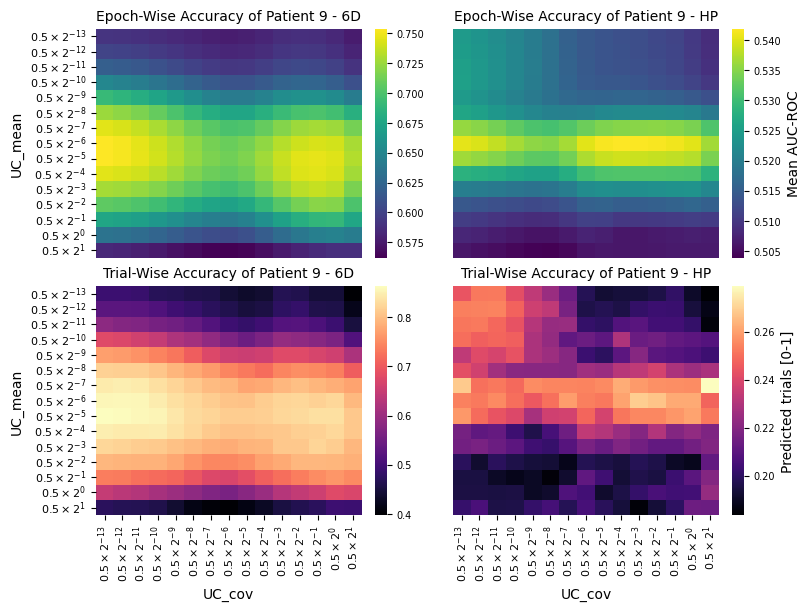

In [67]:
# Plot heatmap
from uc_visualization import plot_reduced_heatmaps
df = pd.read_csv("cc_pilot_results_6D.csv")
pivot_ews1 = df.pivot(index="UC_mean", columns="UC_cov", values="EWS_mean")
pivot_tws1 = df.pivot(index="UC_mean", columns="UC_cov", values="TWS_mean")

df = pd.read_csv("cc_pilot_results_HP.csv")
pivot_ews2 = df.pivot(index="UC_mean", columns="UC_cov", values="EWS_mean")
pivot_tws2 = df.pivot(index="UC_mean", columns="UC_cov", values="TWS_mean")

UC_mean_exponents = np.arange(-13, 2)  
UC_mean_range = 0.5 * (2.0 ** UC_mean_exponents)
UC_cov_exponents = np.arange(-13,2)  
UC_cov_range = 0.5 * (2.0 ** UC_cov_exponents)
print(UC_mean_range)
print(UC_cov_range)

patient_title = "Patient 9"


# Create subplots 
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8, 6), 
                        constrained_layout=True
                        )


# First EWS
sns.heatmap(pivot_ews1, annot=False, fmt=".2f", cmap="viridis", ax=axs[0, 0])
cbar = axs[0, 0].collections[0].colorbar
cbar.set_label(" ", fontsize=10)  # label font size
cbar.ax.tick_params(labelsize=7)
axs[0, 0].set_title("Epoch-Wise Accuracy of Patient 9 - 6D", fontsize=10)
axs[0, 0].set_ylabel("UC_mean", fontsize=10)
axs[0, 0].set_xlabel("")
axs[0,0].set_xticks(np.arange(len(UC_cov_exponents)) + 0.5)
axs[0,0].set_xticklabels([fr"$0.5 \times 2^{{{x}}}$" for x in UC_cov_exponents], rotation=90, fontsize=8)
axs[0,0].set_yticks(np.arange(len(UC_mean_exponents)) + 0.5)
axs[0,0].set_yticklabels([fr"$0.5 \times 2^{{{y}}}$" for y in UC_mean_exponents], rotation=0, fontsize=8)
axs[0,0].tick_params(axis='x', bottom=False, labelbottom=False)  # hide x ticks and labels


# Second EWS
sns.heatmap(pivot_ews2, annot=False, fmt=".2f", cmap="viridis", ax=axs[0, 1], cbar_kws={"label": "Mean AUC-ROC"})
cbar = axs[0, 1].collections[0].colorbar
cbar.set_label("Mean AUC-ROC", fontsize=10)  # label font size
cbar.ax.tick_params(labelsize=7)
axs[0, 1].set_title("Epoch-Wise Accuracy of Patient 9 - HP", fontsize=10)
axs[0, 1].set_ylabel("")
axs[0, 1].set_xlabel("")
axs[0,1].tick_params(axis='x', bottom=False, labelbottom=False)  # hide x ticks and labels
axs[0,1].tick_params(axis='y', left=False, labelleft=False)      # hide y ticks and labels

# First TWS
sns.heatmap(pivot_tws1, annot=False, fmt=".2f", cmap="magma", ax=axs[1, 0])
cbar = axs[1, 0].collections[0].colorbar
cbar.set_label(" ", fontsize=10)  # label font size
cbar.ax.tick_params(labelsize=7)
axs[1, 0].set_title("Trial-Wise Accuracy of Patient 9 - 6D", fontsize=10)
axs[1, 0].set_ylabel("UC_mean", fontsize=10)
axs[1, 0].set_xlabel("UC_cov", fontsize=10)
axs[1,0].set_xticks(np.arange(len(UC_cov_exponents)) + 0.5)
axs[1,0].set_xticklabels([fr"$0.5 \times 2^{{{x}}}$" for x in UC_cov_exponents], rotation=90, fontsize=8)
axs[1,0].set_yticks(np.arange(len(UC_mean_exponents)) + 0.5)
axs[1,0].set_yticklabels([fr"$0.5 \times 2^{{{y}}}$" for y in UC_mean_exponents], rotation=0, fontsize=8)

# Second TWS
sns.heatmap(pivot_tws2, annot=False, fmt=".2f", cmap="magma", ax=axs[1, 1], cbar_kws={"label": "Predicted trials [0-1]"})
cbar = axs[1, 1].collections[0].colorbar
cbar.set_label("Predicted trials [0-1]", fontsize=10)  # label font size
cbar.ax.tick_params(labelsize=7)
axs[1, 1].set_title("Trial-Wise Accuracy of Patient 9 - HP", fontsize=10)
axs[1, 1].set_ylabel("")
axs[1, 1].set_xlabel("UC_cov", fontsize=10)
axs[1,1].set_xticks(np.arange(len(UC_cov_exponents)) + 0.5)
axs[1,1].set_xticklabels([fr"$0.5 \times 2^{{{x}}}$" for x in UC_cov_exponents], rotation=90, fontsize=8)
axs[1,1].set_yticks(np.arange(len(UC_mean_exponents)) + 0.5)
axs[1,1].set_yticklabels([fr"$0.5 \times 2^{{{y}}}$" for y in UC_mean_exponents], rotation=0, fontsize=8)
axs[1,1].tick_params(axis='y', left=False, labelleft=False)      # hide y ticks and labels


# for ax in axs.flat:
#     ax.set_yticklabels([fr"$0.5 \times 2^{{{y}}}$" for y in UC_mean_exponents], rotation=0, fontsize=7)
#     ax.set_xticklabels([fr"$0.5 \times 2^{{{x}}}$" for x in UC_cov_exponents], rotation=90, fontsize=7)


plt.savefig("heatmaps_4grid.svg", bbox_inches="tight")
plt.savefig("heatmaps_4grid.pdf", bbox_inches="tight")
plt.savefig("heatmaps_4grid.png", dpi=600, bbox_inches="tight")

plt.show()    


